# Notebook to review the Kenya Met Hindcasts 

Looking at the hindcasts checking the occurrence of events.
Negative IOD years are 2005, 2010, 2016.

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import ocha_stratus as stratus
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

import re
from utils import parser, helpers
from utils.constants import *
from src.datasources.era5 import fetch_era5_data

In [3]:
import calendar

season_months = [10, 11, 12]
start_date = pd.Timestamp("1997-01-01")
end_date = pd.Timestamp("2025-12-31")

In [4]:
iso3 = "KEN"
blob_name_jul = "ds-aa-ken-drought/raw/July_hindcast.txt"
blob_name_aug = "ds-aa-ken-drought/raw/Aug_hincasts.txt"
blob_name_sep = "ds-aa-ken-drought/raw/September_Hindcasts.txt"

In [5]:
ken_adm = stratus.codab.load_codab_from_fieldmaps(iso3, admin_level=1)
ken_adm0 = stratus.codab.load_codab_from_fieldmaps(iso3, admin_level=0)

In [6]:
final_df = stratus.load_parquet_from_blob(
    "ds-aa-ken-drought/processed/cleaned_hindcasts.parquet",
    stage="dev",
    container_name="projects",
)

In [7]:
# dissolve adm to these areas
arid_union = ken_adm[ken_adm["adm1_name"].isin(arid)].dissolve().reset_index(drop=True)

Now, looking at the 1-in-5 yr clim prob

In [ ]:
neg_iod = [2005, 2010, 2016]
arid_counties = ken_adm[ken_adm["adm1_name"].isin(arid)].to_crs(ken_geo_epsg)

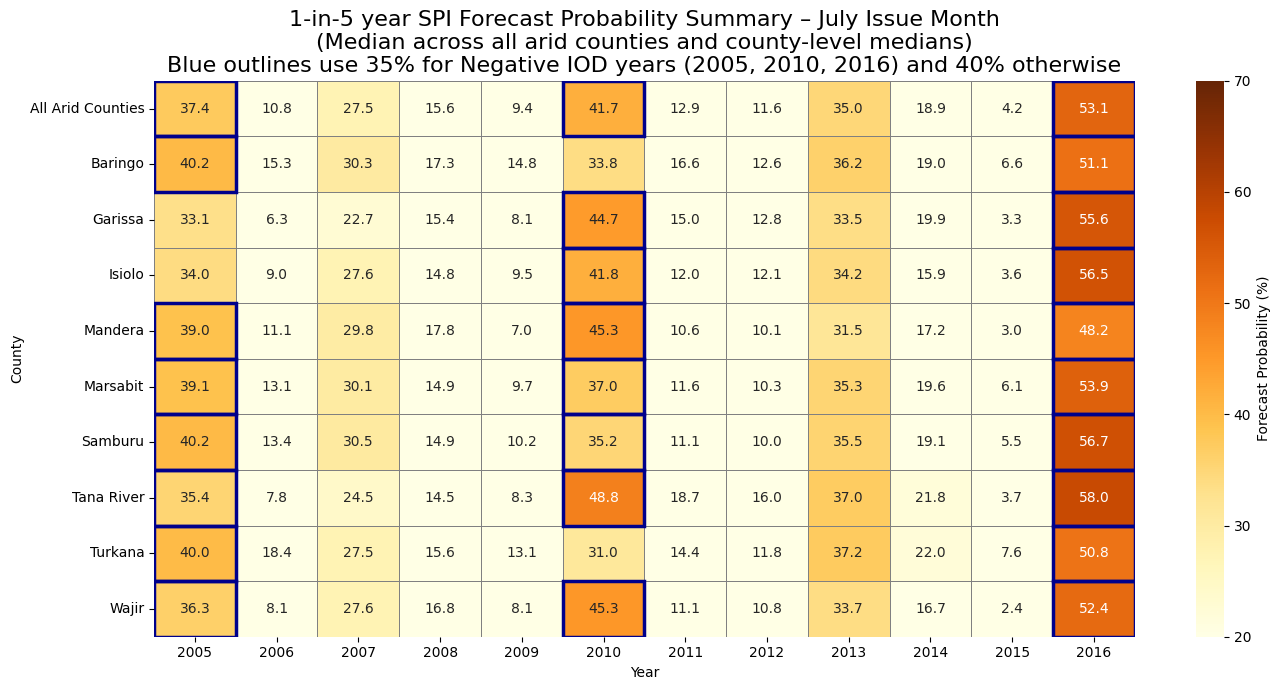

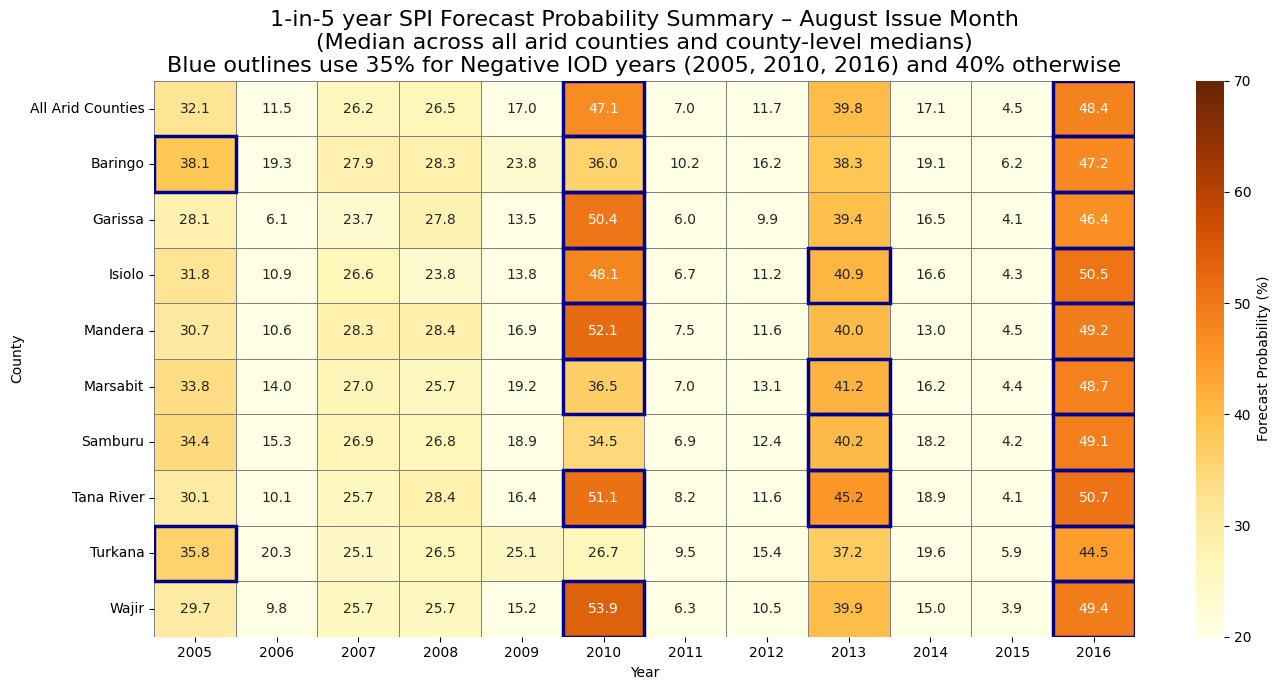

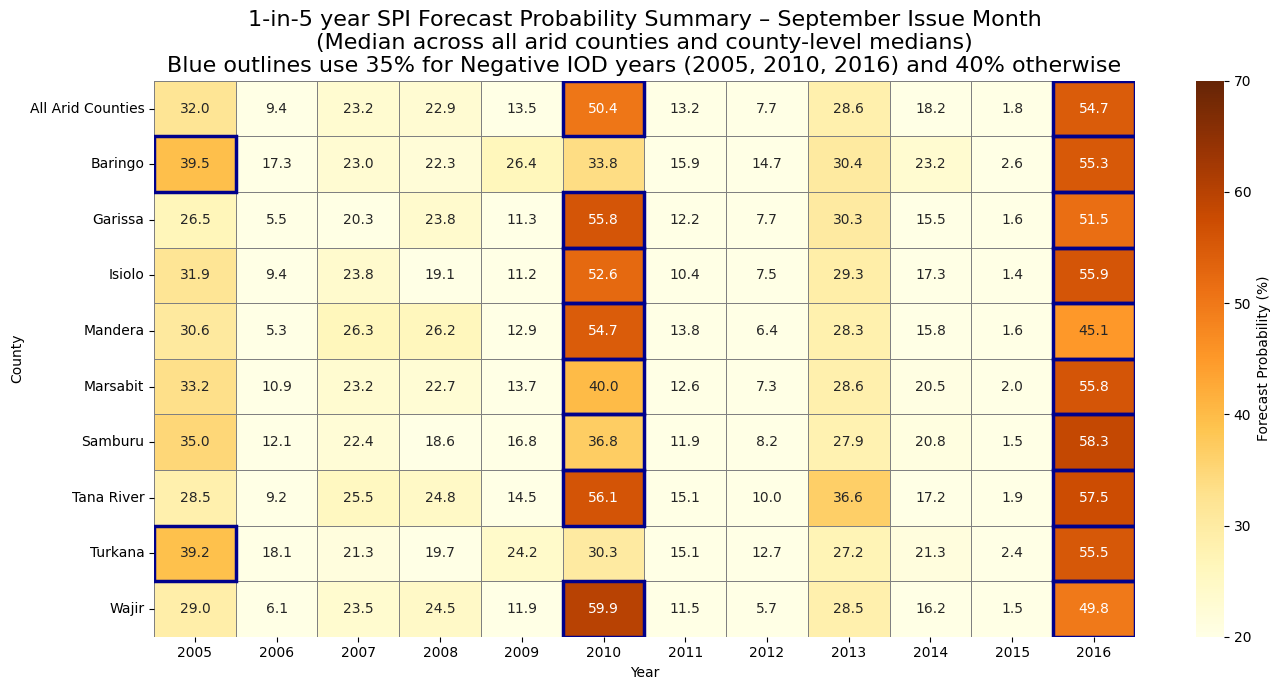

In [20]:
for issue_month in issue_months:

    df = final_df[
        (final_df["C"] == "1")
        & (final_df["clim_prob_type"] == "below")
        & (final_df["issue_month"] == issue_month)
    ].copy()

    gdf_points = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=ken_geo_epsg
    )
    gdf_points = gdf_points.to_crs(ken_epsg)
    gdf_points["geometry"] = gdf_points.geometry.buffer(cell_size / 2, cap_style=3)
    gdf_points = gdf_points.to_crs(ken_geo_epsg)
    gdf_points["year"] = pd.to_datetime(gdf_points["T"]).dt.year

    # Spatial join with counties
    joined = gpd.sjoin(gdf_points, arid_counties, how="inner", predicate="intersects")

    # ------- 1) COUNTY-LEVEL median forecast probability -------
    avg_prob = joined.groupby(["adm1_name", "year"])["value"].median().reset_index()

    heat = avg_prob.pivot_table(index="adm1_name", columns="year", values="value")

    # ------- 2) ALL-ARID-AREA: Probability threshold for driest 40% -------
    # Compute 0.60 quantile for each year over ALL intersecting pixels
    q = (
        joined.groupby("year")["value"]
        .quantile(1 - quantile_RP5_new)
        .rename("All Arid Counties")
        .to_frame()
        .T  # put it as a row
    )

    # ------- 3) ADD to heatmap -------
    heat_with_row = pd.concat([q, heat], axis=0)

    # ------- 4) Plot -------
    plt.figure(figsize=(14, 7))
    sns.heatmap(
        heat_with_row,
        cmap="YlOrBr",
        linewidths=0.5,
        linecolor="gray",
        cbar_kws={"label": "Forecast Probability (%)"},
        annot=True,
        fmt=".1f",
        vmin=20,
        vmax=70,
    )
    threshold = thresholds_RP5.get(issue_month)

    plt.title(
        f"1-in-5 year SPI Forecast Probability Summary – {issue_month} Issue Month\n"
        f"(Median across all arid counties and county-level medians)\n"
        f"Blue outlines use 35% for Negative IOD years (2005, 2010, 2016) and 40% otherwise",
        fontsize=16,
    )
    plt.xlabel("Year")
    plt.ylabel("County")

    ax = plt.gca()
    for i, county in enumerate(heat_with_row.index):
        for j, year in enumerate(heat_with_row.columns):
            val = heat_with_row.loc[county, year]
            if pd.isna(val):
                continue

            threshold = (
                thresholds_RP5_new["Negative"]
                if year in neg_iod
                else thresholds_RP5_new["Non-Negative"]
            )

            if val >= threshold:
                ax.add_patch(
                    plt.Rectangle(
                        (j, i), 1, 1, fill=False, edgecolor="darkblue", linewidth=2.5
                    )
                )

    plt.tight_layout()
    plt.show()

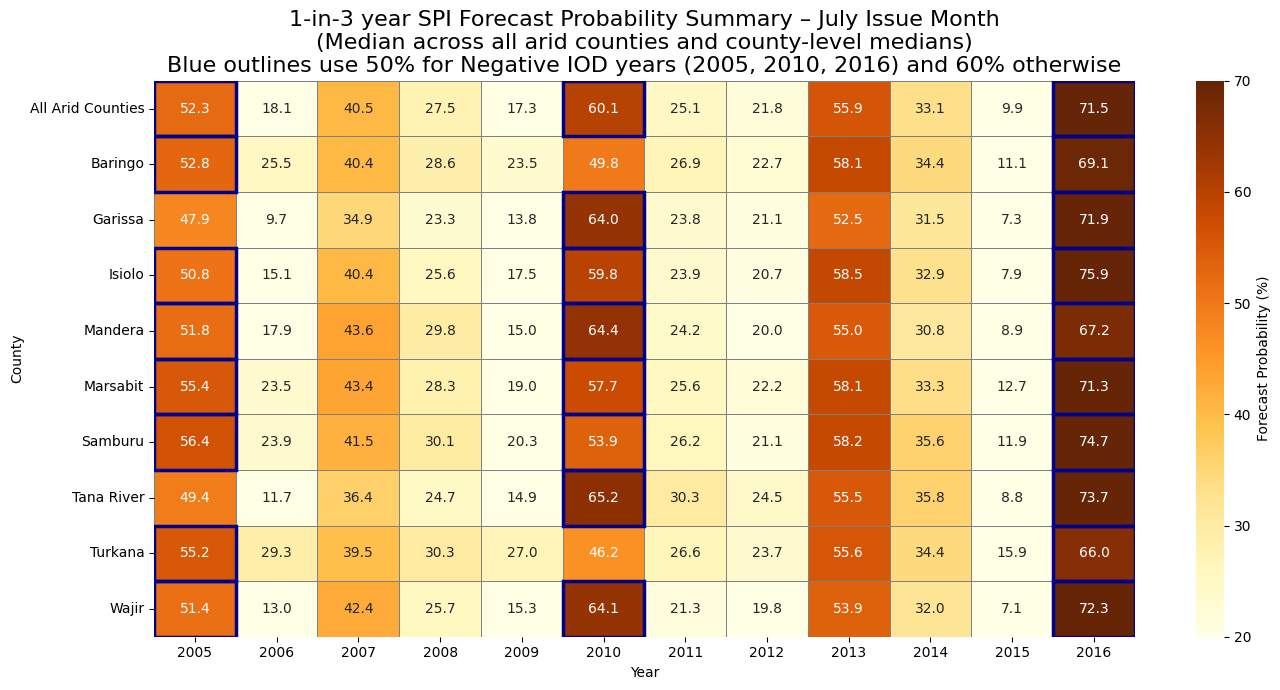

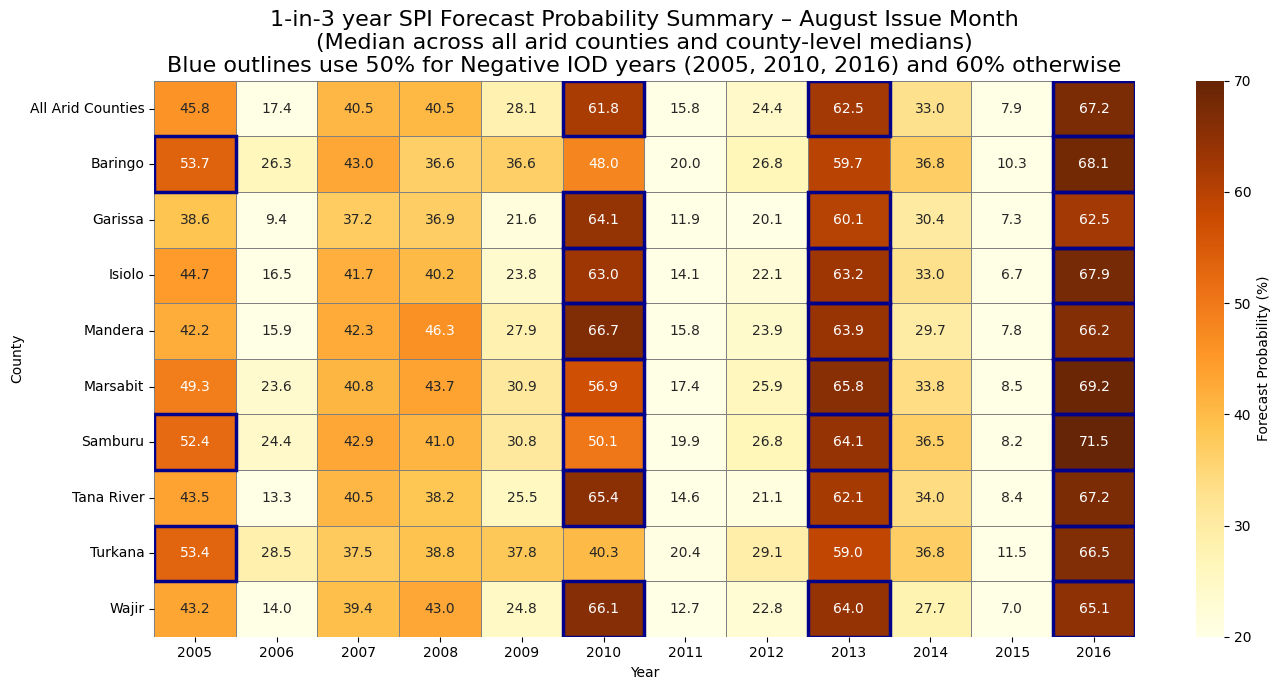

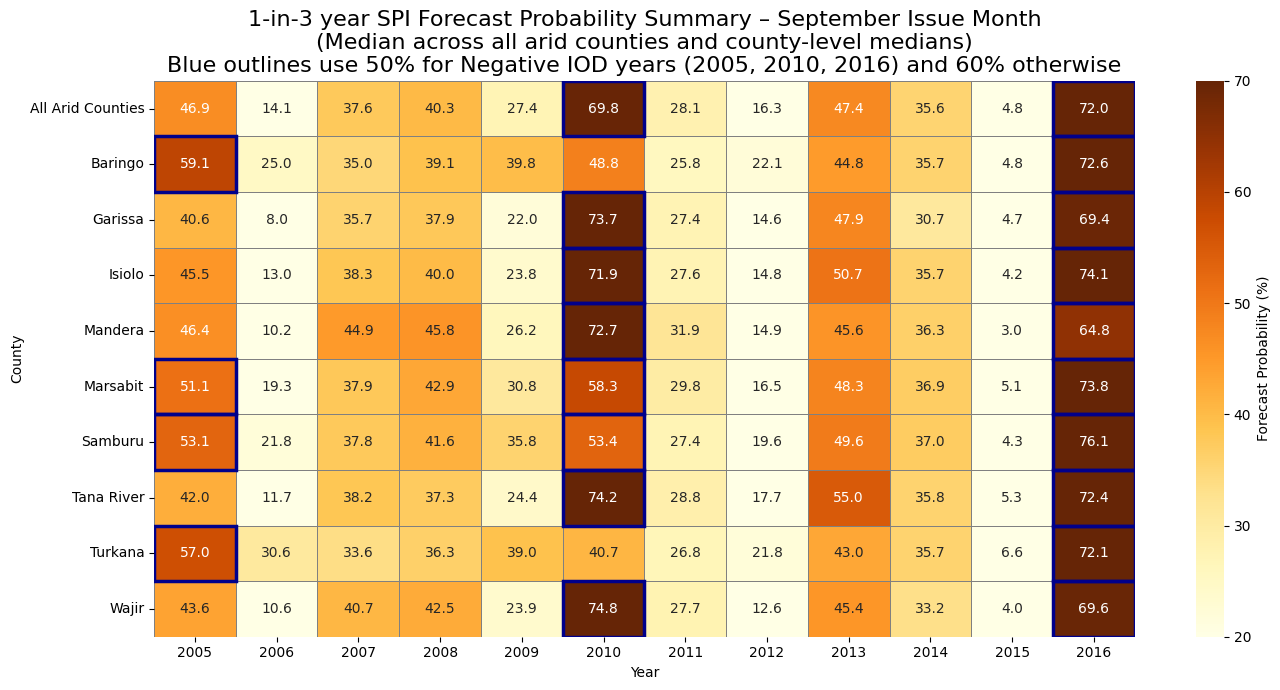

In [21]:
for issue_month in issue_months:

    df = final_df[
        (final_df["C"] == "2")
        & (final_df["clim_prob_type"] == "below")
        & (final_df["issue_month"] == issue_month)
    ].copy()

    gdf_points = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=ken_geo_epsg
    )
    gdf_points = gdf_points.to_crs(ken_epsg)
    gdf_points["geometry"] = gdf_points.geometry.buffer(cell_size / 2, cap_style=3)
    gdf_points = gdf_points.to_crs(ken_geo_epsg)
    gdf_points["year"] = pd.to_datetime(gdf_points["T"]).dt.year

    # Spatial join with counties
    joined = gpd.sjoin(gdf_points, arid_counties, how="inner", predicate="intersects")

    # ------- 1) COUNTY-LEVEL median forecast probability -------
    avg_prob = joined.groupby(["adm1_name", "year"])["value"].median().reset_index()

    heat = avg_prob.pivot_table(index="adm1_name", columns="year", values="value")

    # ------- 2) ALL-ARID-AREA: Probability threshold for driest 40% -------
    # Compute 0.60 quantile for each year over ALL intersecting pixels
    q = (
        joined.groupby("year")["value"]
        .quantile(1 - quantile_RP3_new)
        .rename("All Arid Counties")
        .to_frame()
        .T  # put it as a row
    )

    # ------- 3) ADD to heatmap -------
    heat_with_row = pd.concat([q, heat], axis=0)

    # ------- 4) Plot -------
    plt.figure(figsize=(14, 7))
    sns.heatmap(
        heat_with_row,
        cmap="YlOrBr",
        linewidths=0.5,
        linecolor="gray",
        cbar_kws={"label": "Forecast Probability (%)"},
        annot=True,
        fmt=".1f",
        vmin=20,
        vmax=70,
    )
    threshold = thresholds_RP5.get(issue_month)

    plt.title(
        f"1-in-3 year SPI Forecast Probability Summary – {issue_month} Issue Month\n"
        f"(Median across all arid counties and county-level medians)\n"
        f"Blue outlines use 50% for Negative IOD years (2005, 2010, 2016) and 60% otherwise",
        fontsize=16,
    )
    plt.xlabel("Year")
    plt.ylabel("County")

    ax = plt.gca()
    for i, county in enumerate(heat_with_row.index):
        for j, year in enumerate(heat_with_row.columns):
            val = heat_with_row.loc[county, year]
            if pd.isna(val):
                continue

            threshold = (
                thresholds_RP3_new["Negative"]
                if year in neg_iod
                else thresholds_RP3_new["Non-Negative"]
            )

            if val >= threshold:
                ax.add_patch(
                    plt.Rectangle(
                        (j, i), 1, 1, fill=False, edgecolor="darkblue", linewidth=2.5
                    )
                )

    plt.tight_layout()
    plt.show()